In [1]:
import time

import torch
from matplotlib import pyplot as plt

from torch_scattering import multislice

# Effect of `n_slices` on multislice accuracy

Build a 3D scattering potential with many Gaussian blobs arranged along a diagonal line (same volume size as `scattering_model_comparison.ipynb`, but denser), then compare the multislice exit wave as `n_slices` is coarsened from one chunk per slice down to only 16 chunks.

In [2]:
N_XY = 64
N_Z = 512
PIXEL_SIZE = 1.0  # Angstrom
ENERGY = 100.0  # keV

# Blobs equally spaced along Z, moving left-to-right in X -> a diagonal line
N_BLOBS = 100
Z_POSITIONS = torch.linspace(56, N_Z - 56, N_BLOBS)
X_POSITIONS = torch.linspace(20, N_XY - 20, N_BLOBS)
Y_CENTER = N_XY / 2

BLOBS = [
    {"center": (float(z), Y_CENTER, float(x)), "sigma": 1.0, "amplitude": 300.0}
    for z, x in zip(Z_POSITIONS, X_POSITIONS)
]

In [3]:
def gaussian_blob(
    coords: torch.Tensor, center: tuple[float, float, float], sigma: float, amplitude: float
) -> torch.Tensor:
    """Evaluate an isotropic 3D Gaussian at each point in `coords`."""
    r2 = ((coords - torch.tensor(center)) ** 2).sum(dim=-1)
    return amplitude * torch.exp(-r2 / (2 * sigma**2))

In [4]:
zz, yy, xx = torch.meshgrid(
    torch.arange(N_Z), torch.arange(N_XY), torch.arange(N_XY), indexing="ij"
)
coords = torch.stack([zz, yy, xx], dim=-1).float()

potential = torch.zeros(N_Z, N_XY, N_XY)
for blob in BLOBS:
    potential += gaussian_blob(coords, **blob)

# multislice expects a complex-valued potential, batched as (B, Z, Y, X)
potential = potential.to(torch.complex64)[None]
potential.shape

torch.Size([1, 512, 64, 64])

take a look at the central Y-slice of the potential (Z vs X) to see the diagonal line of blobs

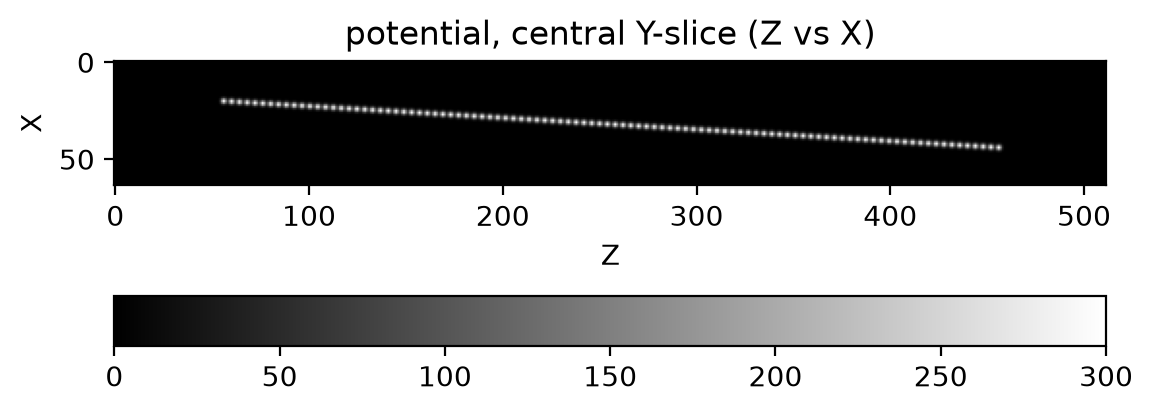

In [5]:
fig, ax = plt.subplots(dpi=200)
im = ax.imshow(potential[0, :, N_XY // 2, :].real.T, cmap="gray", aspect="auto")
ax.set_title("potential, central Y-slice (Z vs X)")
ax.set_xlabel("Z")
ax.set_ylabel("X")
fig.colorbar(im, ax=ax, location='bottom')
ax.set_aspect(1)
plt.show()

## Compute the exit wave with multislice at decreasing `n_slices`

`n_slices=512` (equal to `N_Z`, i.e. `n_slices=None`) propagates every true slice individually and is the most accurate setting. Coarser values group slices into thicker slabs, trading accuracy for speed.

In [6]:
N_SLICES_LIST = [512, 256, 128, 64, 32, 16]

waves = {}
times = {}
for n_slices in N_SLICES_LIST:
    start = time.perf_counter()
    waves[n_slices] = multislice(potential, pixel_size=PIXEL_SIZE, energy=ENERGY, n_slices=n_slices)
    times[n_slices] = time.perf_counter() - start
    print(f"n_slices={n_slices:>4d}  exit wave time={times[n_slices]:.4f} s")

n_slices= 512  exit wave time=3.2269 s
n_slices= 256  exit wave time=1.6474 s
n_slices= 128  exit wave time=0.9139 s
n_slices=  64  exit wave time=0.4194 s
n_slices=  32  exit wave time=0.2059 s
n_slices=  16  exit wave time=0.1042 s


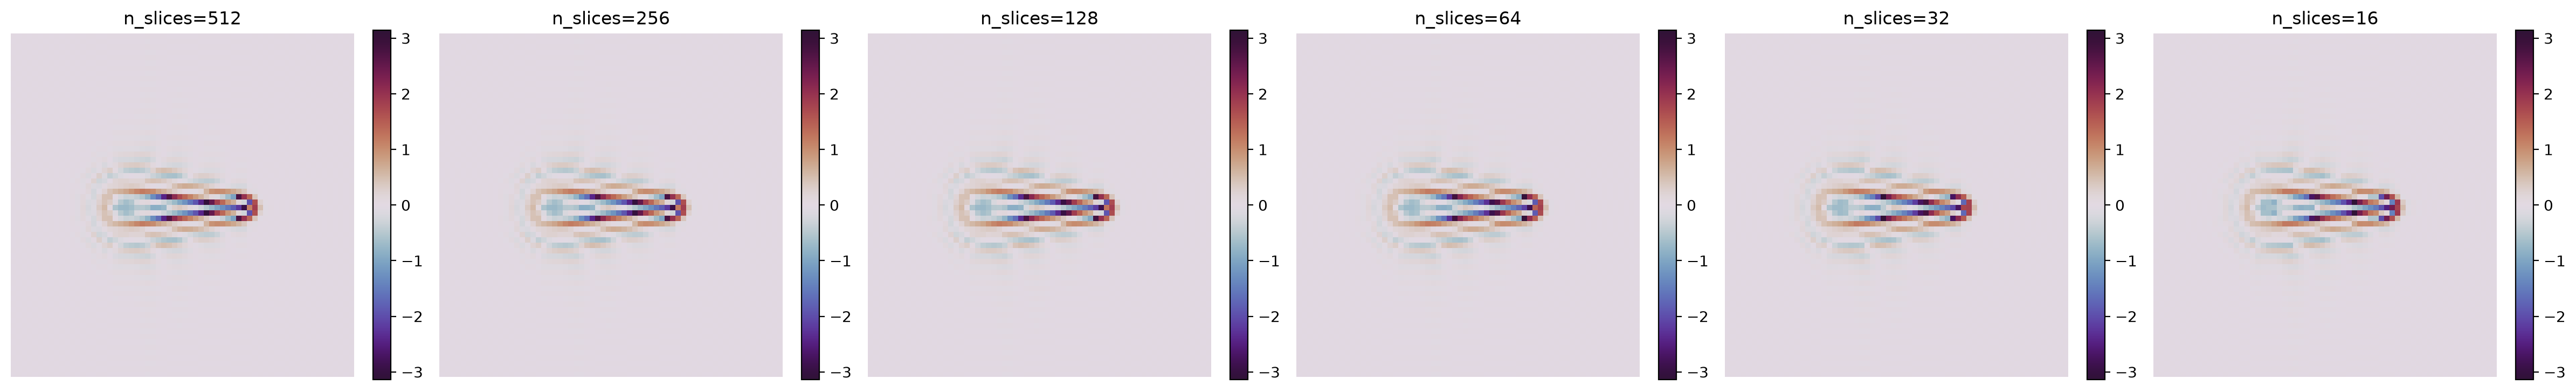

In [7]:
fig, axes = plt.subplots(1, len(N_SLICES_LIST), figsize=(4 * len(N_SLICES_LIST), 4), dpi=200)
for ax, n_slices in zip(axes, N_SLICES_LIST):
    im = ax.imshow(waves[n_slices][0].angle(), cmap="twilight_shifted", vmin=-torch.pi, vmax=torch.pi)
    ax.set_title(f"n_slices={n_slices}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## Quantitative error vs `n_slices`

Use the finest setting (`n_slices=512`, one chunk per true slice) as the reference and measure how much the exit-wave phase and amplitude drift as slices are coarsened.

In [8]:
reference = waves[512]

phase_rmse = []
amplitude_rmse = []
for n_slices in N_SLICES_LIST:
    dphase = (waves[n_slices].angle() - reference.angle())
    damplitude = (waves[n_slices].abs() - reference.abs())
    phase_rmse.append(dphase.pow(2).mean().sqrt().item())
    amplitude_rmse.append(damplitude.pow(2).mean().sqrt().item())

for n_slices, p_rmse, a_rmse in zip(N_SLICES_LIST, phase_rmse, amplitude_rmse):
    print(f"n_slices={n_slices:>4d}  phase RMSE={p_rmse:.3e} rad  amplitude RMSE={a_rmse:.3e}")

n_slices= 512  phase RMSE=0.000e+00 rad  amplitude RMSE=0.000e+00
n_slices= 256  phase RMSE=2.450e-03 rad  amplitude RMSE=1.097e-03
n_slices= 128  phase RMSE=7.320e-03 rad  amplitude RMSE=3.209e-03
n_slices=  64  phase RMSE=1.717e-02 rad  amplitude RMSE=7.515e-03
n_slices=  32  phase RMSE=1.251e-01 rad  amplitude RMSE=1.608e-02
n_slices=  16  phase RMSE=2.114e-01 rad  amplitude RMSE=3.318e-02


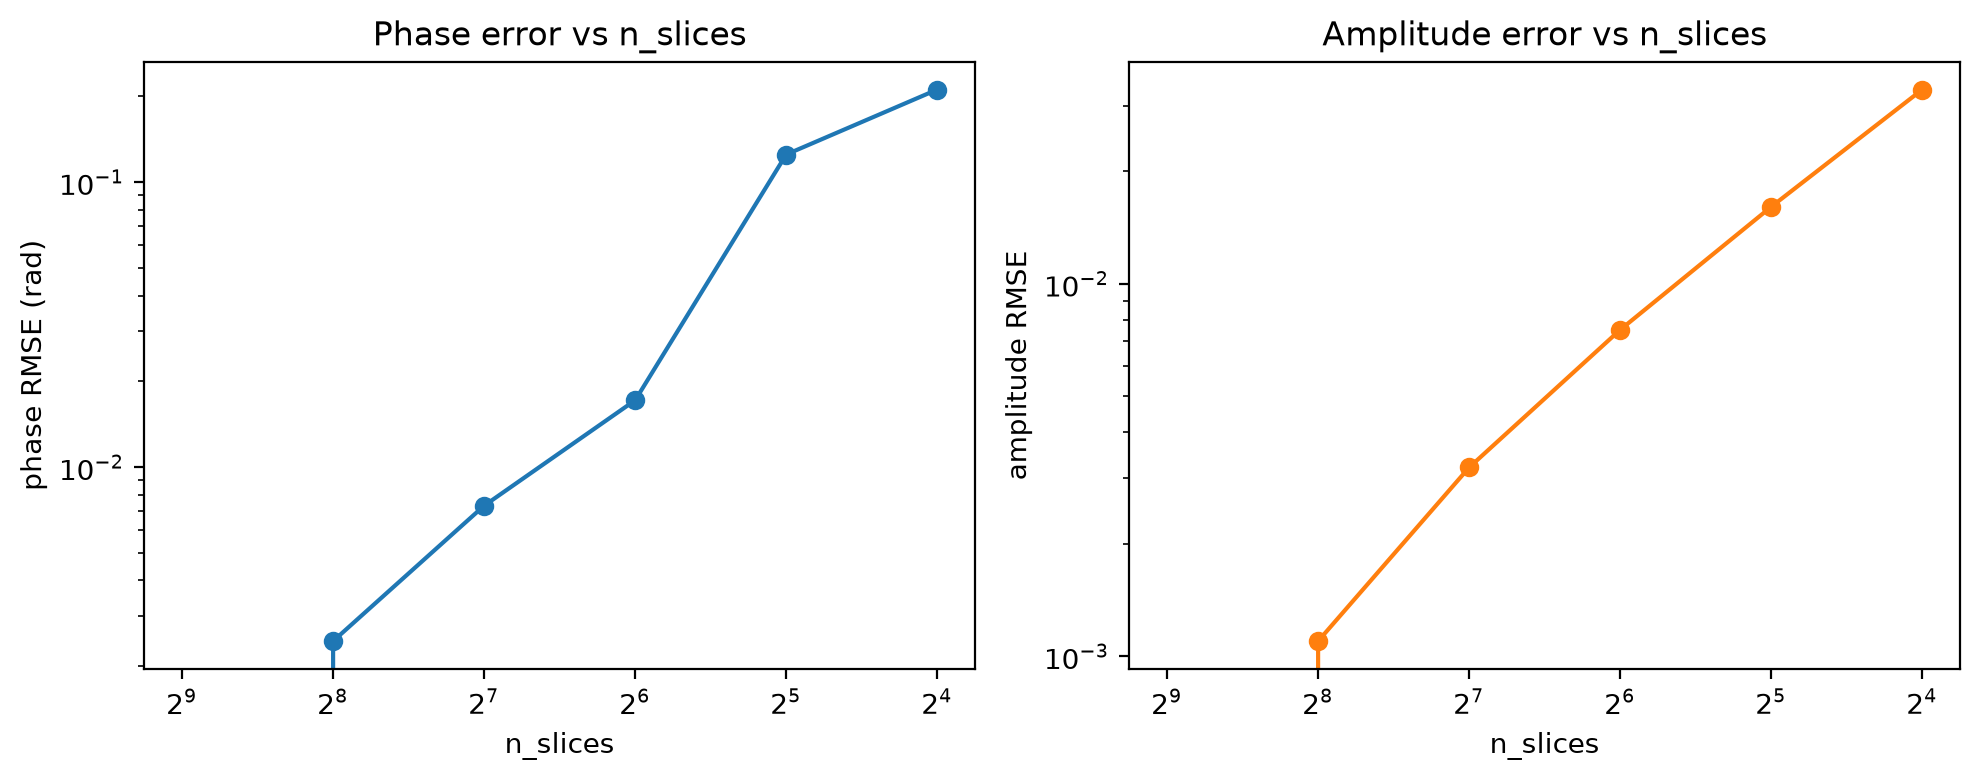

In [9]:
fig, (ax_phase, ax_amp) = plt.subplots(1, 2, figsize=(10, 4), dpi=200)

ax_phase.plot(N_SLICES_LIST, phase_rmse, marker="o")
ax_phase.set_xscale("log", base=2)
ax_phase.set_yscale("log")
ax_phase.set_xlabel("n_slices")
ax_phase.set_ylabel("phase RMSE (rad)")
ax_phase.set_title("Phase error vs n_slices")
ax_phase.invert_xaxis()

ax_amp.plot(N_SLICES_LIST, amplitude_rmse, marker="o", color="tab:orange")
ax_amp.set_xscale("log", base=2)
ax_amp.set_yscale("log")
ax_amp.set_xlabel("n_slices")
ax_amp.set_ylabel("amplitude RMSE")
ax_amp.set_title("Amplitude error vs n_slices")
ax_amp.invert_xaxis()

plt.tight_layout()
plt.show()